# 01 — Data Exploration

IMDB Large Movie Review Dataset (Maas et al., 2011): 50,000 movie reviews, already labeled positive/negative, split 25k train / 25k test, perfectly balanced.

Label meaning: **0 = negative, 1 = positive**.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # make `src` importable

In [2]:
from src.data import load_imdb

train_df, test_df = load_imdb()
print(train_df.shape, test_df.shape)

(25000, 2) (25000, 2)


## Class balance

Perfectly balanced by construction — no resampling needed.

In [3]:
train_df['label'].value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

## Review length

Reviews are long-form text (hundreds of words), which favors TF-IDF with bigrams.

count    25000.0
mean       233.8
std        173.7
min         10.0
25%        127.0
50%        174.0
75%        284.0
max       2470.0
Name: text, dtype: float64


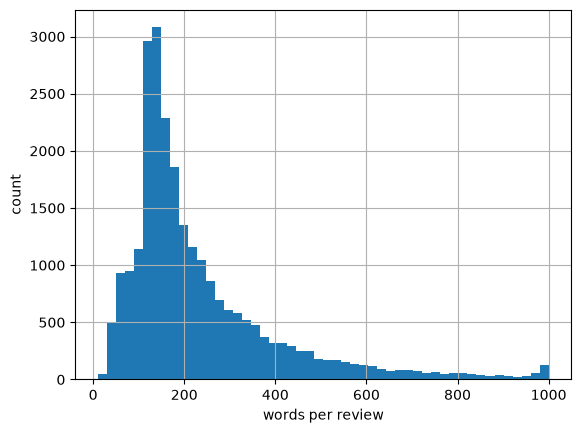

In [4]:
lengths = train_df['text'].str.split().str.len()
ax = lengths.clip(upper=1000).hist(bins=50)
ax.set_xlabel('words per review'); ax.set_ylabel('count');
print(lengths.describe().round(1))

## Sample reviews

In [5]:
for label, name in [(0, 'NEGATIVE'), (1, 'POSITIVE')]:
    sample = train_df[train_df.label == label].iloc[0]['text'][:400]
    print(f'--- {name} ---')
    print(sample)
    print()

--- NEGATIVE ---
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student name

--- POSITIVE ---
Zentropa has much in common with The Third Man, another noir-like film set among the rubble of postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who gets emotionally involved with a woman he doesn't really understand, and whose naivety is all the more striking in contrast with the natives.<br /><br />But I'd have to say that The Third Man has a more well-

